<a href="https://colab.research.google.com/github/mikolajbaraniak-3232/analiza-danych/blob/main/13_04_2026_MB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()
y = data.target
x=data.data

1. sprawdz liczbe wszystkich przypadkow

In [8]:
print(f"Liczba wszystkich przypadków: {len(y)}")

Liczba wszystkich przypadków: 569


2. sprawdz liczbe przypadkow raka zlosliwego

In [9]:
num_malignant = (y == 0).sum()
print(f"Liczba przypadków raka złośliwego: {num_malignant}")

Liczba przypadków raka złośliwego: 212


3. narysuj histogram sredniego obszaru (mean area)

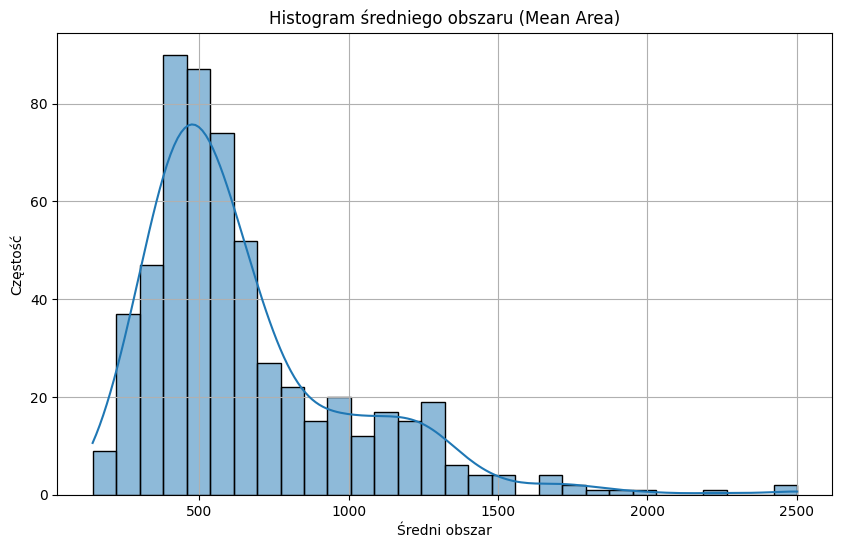

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Znajdź indeks kolumny 'mean area'
feature_names = data.feature_names
mean_area_idx = list(feature_names).index('mean area')

# Wybierz dane dla 'mean area'
mean_area_data = x[:, mean_area_idx]

# Narysuj histogram
plt.figure(figsize=(10, 6))
sns.histplot(mean_area_data, bins=30, kde=True)
plt.title('Histogram średniego obszaru (Mean Area)')
plt.xlabel('Średni obszar')
plt.ylabel('Częstość')
plt.grid(True)
plt.show()

4. narysuj wykres rozrzutu (scatterplot) sredniego obszaru od klasyfikacji (uzyj sns.regplot)

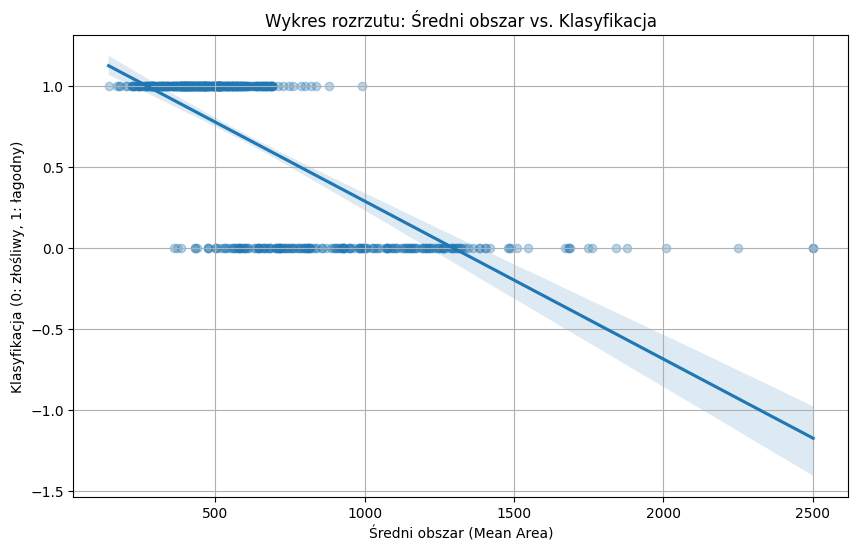

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x=mean_area_data, y=y, scatter_kws={'alpha':0.3})
plt.title('Wykres rozrzutu: Średni obszar vs. Klasyfikacja')
plt.xlabel('Średni obszar (Mean Area)')
plt.ylabel('Klasyfikacja (0: złośliwy, 1: łagodny)')
plt.grid(True)
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression

1. sprawdz jesli dane nie sa ustandaryzowane zrob to

In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Sprawdź bieżący stan danych
current_mean = np.mean(x)
current_std = np.std(x)

print(f"Bieżąca średnia danych X: {current_mean:.2f}")
print(f"Bieżące odchylenie standardowe danych X: {current_std:.2f}")

# Sprawdź, czy dane są już ustandaryzowane (średnia bliska 0, odchylenie standardowe bliskie 1)
if not (np.isclose(current_mean, 0.0, atol=1e-2) and np.isclose(current_std, 1.0, atol=1e-2)):
    print("Dane nie są ustandaryzowane. Rozpoczynam standaryzację...")
    scaler = StandardScaler()
    x = scaler.fit_transform(x)
    print("Dane zostały ustandaryzowane.")

    # Sprawdź ponownie po standaryzacji
    new_mean = np.mean(x)
    new_std = np.std(x)
    print(f"Średnia danych X po standaryzacji: {new_mean:.2f}")
    print(f"Odchylenie standardowe danych X po standaryzacji: {new_std:.2f}")
else:
    print("Dane są już ustandaryzowane.")

Bieżąca średnia danych X: -0.00
Bieżące odchylenie standardowe danych X: 1.00
Średnia danych X po standaryzacji: 0.00
Odchylenie standardowe danych X po standaryzacji: 1.00
Dane zostały ustandaryzowane.


podziel zbior danych na testowy 30% i uczący 70%

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(f"Rozmiar zbioru treningowego X: {x_train.shape}")
print(f"Rozmiar zbioru testowego X: {x_test.shape}")

Rozmiar zbioru treningowego X: (398, 30)
Rozmiar zbioru testowego X: (171, 30)


zwizualizuj wyniki używając

1.   from sklearn.metrics import ConfusionMatrixDisplay, confusion matrix
2.  from sklearn.metrics import RocCurveDisplay, roc curve



<Figure size 800x600 with 0 Axes>

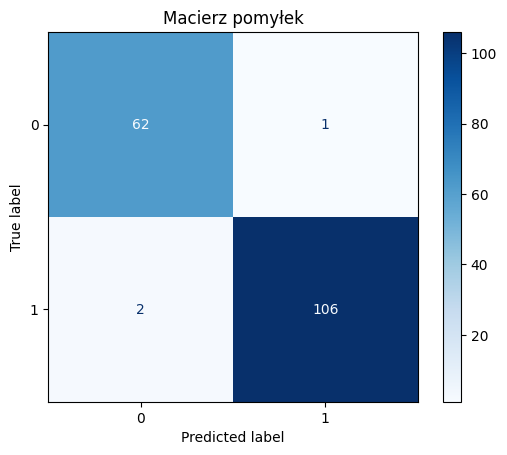

<Figure size 800x600 with 0 Axes>

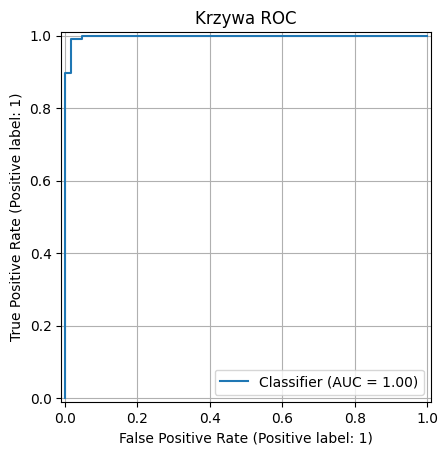

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1] # Prawdopodobieństwa dla klasy pozytywnej (1)

# 1. Wizualizacja macierzy pomyłek (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
plt.title('Macierz pomyłek')
plt.grid(False)


# 2. Wizualizacja krzywej ROC (Receiver Operating Characteristic)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('Krzywa ROC')
plt.grid(True)


porownaj klasyfikatory regresji logositycznej i knn metodą ROC i AUC

In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


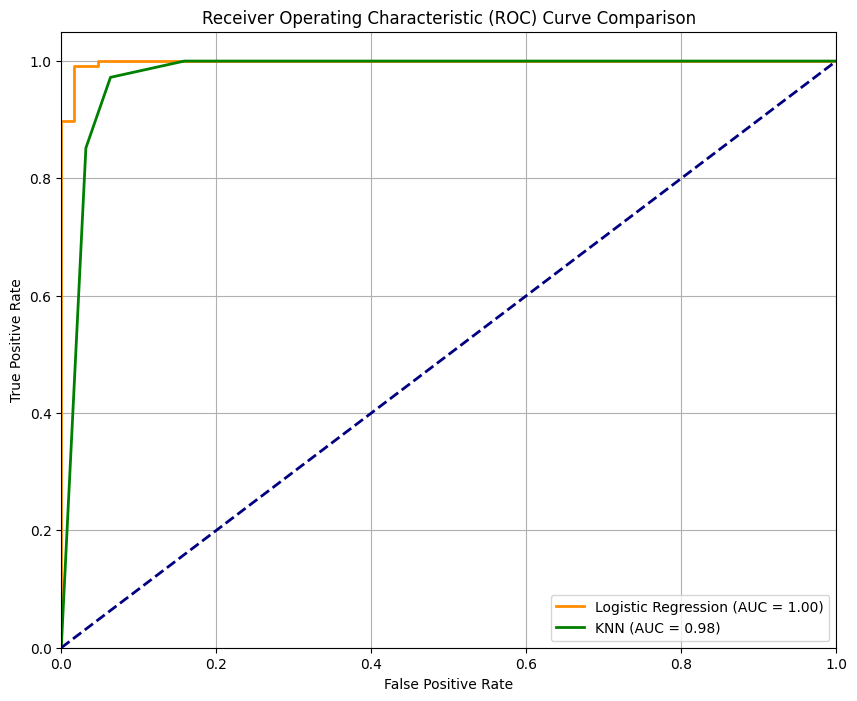

AUC for Logistic Regression: 1.00
AUC for KNN: 0.98


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression (already trained 'model' from previous cell wLpg33t_1OmE)
# y_proba for Logistic Regression is already calculated as y_proba
roc_auc_lr = auc(fpr, tpr)

# K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
y_proba_knn = knn_model.predict_proba(x_test)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plotting ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, color='green', lw=2, label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC for Logistic Regression: {roc_auc_lr:.2f}")
print(f"AUC for KNN: {roc_auc_knn:.2f}")